# Week6 - Classifier Evaluation Assignment

- Complete this Jupyter Notebook.  
- Execute the initial cells and answer the numbered questions.  
- Don't import other libraries.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

results = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/lab-evaluation-data.csv')
results.head()

,actual,prob
0,0.0,0.380052
1,1.0,0.827923
2,1.0,0.929093
3,1.0,0.472508
4,1.0,0.906988


## Data Definitions
- `actual`: Whether the event was true or not. A value of 1.0 is True and 0.0 is False.  
- `prob`: The probability that the event was True. This is estimated from a classification model.

## Question 1
- Determine the distribution of the actual event.
- Would you be concerned about bias due to imbalance?

In [8]:
#counting how many times each value appear in the columb
distribution = results['actual'].value_counts()

#sorting the counts by index so that 0 appears before 1
distribution = distribution.sort_index()

#printing the distribution of the actual event
print(distribution)

#calculateing the percentage distribution of each class
percentage = results['actual'].value_counts(normalize=True).sort_index()

#printing the percentage distribution to check if the dataset is balanced
print(percentage)

actual
0.0    2000
1.0    3000
Name: count, dtype: int64
actual
0.0    0.4
1.0    0.6
Name: proportion, dtype: float64



The actual event distribution shows that there are 3000 positive cases which equals 1.0 and 2000 negative cases the results show 60% positive cases and 40% negative cases and the dataset contains a minor class imbalance but it does not produce important model bias the case will not experience serious difficulties because of class imbalance.


## Question 2
- Create a histogram that shows the distribution of the probabilities for the True and False classes.  
- Describe what you observe.

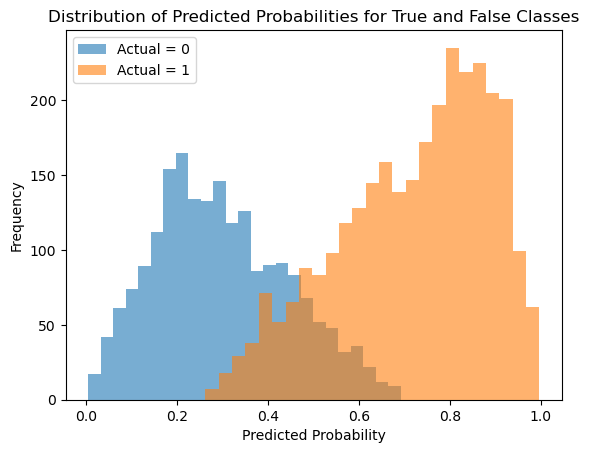

In [10]:
# separateing the probabilities for actual False events
false_probs = results[results['actual'] == 0]['prob']

#separateing the probabilities for actual True events
true_probs = results[results['actual'] == 1]['prob']

#createing a histogram for the False class probabilities
plt.hist(false_probs, bins=25, alpha=0.6, label='Actual = 0')

#createing a histogram for the True class probabilities
plt.hist(true_probs, bins=25, alpha=0.6, label='Actual = 1')

#adding labels and legend to make the plot easier to understand
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Probabilities for True and False Classes")
plt.legend()
plt.show()

The histogram shows that observations with actual value 0 mostly have lower predicted probabilities while observations with actual value 1 generally have higher predicted probabilities there is a small overlap between the two distributions around the middle probability range which shows some uncertainty in predictions overall the model appears to separate the two classes very well.

## Question 3
- Create a simple confusion matrix. Use `0.5` as the threshold for whether an observation should be considered True or False.  
- Comment on what you observe.

In [11]:
#createing predictions using 0.5 as the threshold
results['predicted'] = (results['prob'] >= 0.5).astype(int)

#counting True Positives (predicted 1 and actual 1)
TP = len(results[(results['predicted'] == 1) & (results['actual'] == 1)])

#counting True Negatives (predicted 0 and actual 0)
TN = len(results[(results['predicted'] == 0) & (results['actual'] == 0)])

#counting False Positives and False Negatives
FP = len(results[(results['predicted'] == 1) & (results['actual'] == 0)])
FN = len(results[(results['predicted'] == 0) & (results['actual'] == 1)])

#displaying the confusion matrix
confusion_matrix = pd.DataFrame([[TP, FP], [FN, TN]],
                                index=['Actual 1', 'Actual 0'],
                                columns=['Predicted 1', 'Predicted 0'])
print(confusion_matrix)

          Predicted 1  Predicted 0
Actual 1         2623          210
Actual 0          377         1790


Using a threshold of 0.5 the confusion matrix shows that the model correctly classifies most observations there are 2623 true positives and 1790 true negatives which shows many correct prediction but there are also 377 false positives and 210 false negatives this means the model makes some incorrect predictions overall the classifier performs reasonably well but still has some misclassification due to overlapping probability distributions.

## Question 4
- Calculate the accuracy, precision, and recall `without` using any pre-built functions.
- Which measure would you use if this was your model and why?

In [12]:
#defineing the confusion matrix values
TP = 2623
TN = 1790
FP = 377
FN = 210

#calculateing accuracy manually
accuracy = (TP + TN) / (TP + TN + FP + FN)

#calculateing precision manually
precision = TP / (TP + FP)

#calculateing recall manually
recall = TP / (TP + FN)

#printing the evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.8826
Precision: 0.8743333333333333
Recall: 0.9258736321920226


The model achieves an accuracy of 0.8826 which shows that about 88% of the predictions are correct the precision is 0.8743 that means that when the model predicts a positive event it is correct about 87% of the time the recall is 0.9259 showing that the model correctly identifies most of the actual positive cases if this was my model I would focus on recall since it ensures that most true events are detected and reduces the number of missed positive cases.

## Question 5
- Construct a ROC curve plot.  
- Comment on the fit of the model based on this chart.

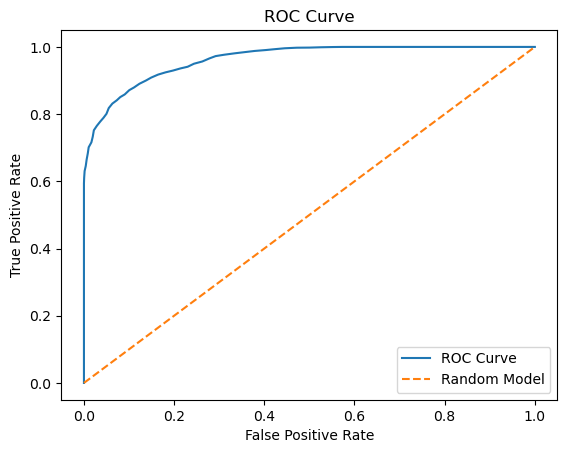

In [6]:
#createing thresholds from 0 to 1
thresholds = np.linspace(0, 1, 100)

#lists to store TPR and FPR values
tpr_list = []
fpr_list = []

#loop through each threshold
for t in thresholds:
    
    #createing predicted labels based on threshold
    predicted = (results['prob'] >= t).astype(int)
    
    #calculateing TP, TN, FP, FN
    TP = len(results[(predicted == 1) & (results['actual'] == 1)])
    TN = len(results[(predicted == 0) & (results['actual'] == 0)])
    FP = len(results[(predicted == 1) & (results['actual'] == 0)])
    FN = len(results[(predicted == 0) & (results['actual'] == 1)])
    
    #calculateing True Positive Rate
    TPR = TP / (TP + FN)
    
    #calculateing False Positive Rate
    FPR = FP / (FP + TN)
    
    #storeing the values
    tpr_list.append(TPR)
    fpr_list.append(FPR)

#ploting the ROC curve
plt.plot(fpr_list, tpr_list, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve shows that the performance of the classifier across different classification thresholds by plotting the True Positive Rate (TPR) against the False Positive Rate (FPR) in this plot the ROC curve rises sharply toward the top-left corner and stays well above the diagonal line which shows the performance of a random classifier this tells us that the model has a strong ability to distinguish between the positive and negative classes.

The steep rise of the curve at the beginning shows that the model is able to correctly identify a large number of true positive cases while keeping the number of false positives relatively low as the threshold changes the curve continues to remain close to the top of the graph which tells us that the model maintains good classification performance across different threshold values overall the shape of the ROC curve indicates that the model fits the data well and provides reliable predictions for distinguishing between the two classes.